# Week 2 — Notebook 1: Exploratory Data Analysis (EDA)
**Project:** ML-Based IDS for IoT Networks | **Student:** Aryan Thapa | AM.SC.P2CSN25003
**Dataset:** Bot-IoT — Best 10 Features Version (Koroniotis et al., 2019)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, glob, os
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print('Libraries loaded')

Libraries loaded


## 1. Load Dataset

In [2]:
# Robust path handling for loading data
if os.path.exists('../data/raw/'):
    RAW_PATH = '../data/raw/'
elif os.path.exists('./data/raw/'):
    RAW_PATH = './data/raw/'
else:
    print(f"Current working directory: {os.getcwd()}")
    raise FileNotFoundError("Could not find data/raw/ directory. Check working directory above.")

csv_files = glob.glob(os.path.join(RAW_PATH, '*.csv'))
print(f'Found {len(csv_files)} CSV files:')
for f in csv_files:
    print(f'  {os.path.basename(f)}')

if len(csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in {os.path.abspath(RAW_PATH)}")

df = pd.concat(
    [pd.read_csv(f, sep=';', low_memory=False) for f in csv_files],
    ignore_index=True
)

# Drop unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print(f'\nTotal records: {len(df):,}')
print(f'Total columns: {len(df.columns)}')
print(f'Columns: {df.columns.tolist()}')

Found 3 CSV files:
  UNSW_2018_IoT_Botnet_Final_10_Best.csv
  UNSW_2018_IoT_Botnet_Final_10_best_Testing.csv
  UNSW_2018_IoT_Botnet_Final_10_best_Training.csv

Total records: 7,337,044
Total columns: 20
Columns: ['pkSeqID', 'proto', 'saddr', 'sport', 'daddr', 'dport', 'seq', 'stddev', 'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP', 'drate', 'srate', 'max', 'attack', 'category', 'subcategory', 'pkSeqID,proto,saddr,sport,daddr,dport,seq,stddev,N_IN_Conn_P_SrcIP,min,state_number,mean,N_IN_Conn_P_DstIP,drate,srate,max,attack,category,subcategory']


## 2. Basic Inspection

In [3]:
print('=== SHAPE ===')
print(df.shape)
print('\n=== DATA TYPES ===')
print(df.dtypes.to_string())
print('\n=== FIRST 5 ROWS ===')
df.head()

=== SHAPE ===
(7337044, 20)

=== DATA TYPES ===
pkSeqID                                                                                                                                                   float64
proto                                                                                                                                                      object
saddr                                                                                                                                                      object
sport                                                                                                                                                      object
daddr                                                                                                                                                      object
dport                                                                                                                                         

,pkSeqID,proto,saddr,sport,daddr,dport,seq,stddev,N_IN_Conn_P_SrcIP,min,state_number,mean,N_IN_Conn_P_DstIP,drate,srate,max,attack,category,subcategory,"pkSeqID,proto,saddr,sport,daddr,dport,seq,stddev,N_IN_Conn_P_SrcIP,min,state_number,mean,N_IN_Conn_P_DstIP,drate,srate,max,attack,category,subcategory"
0,1.0,tcp,192.168.100.147,49960,192.168.100.7,80,9.0,0.068909,75.0,0.000000,1.0,0.068909,96.0,14.511893,0.566862,0.137818,1.0,DoS,HTTP,NaN
1,2.0,arp,192.168.100.7,-1,192.168.100.147,-1,10.0,0.000000,2.0,0.000131,2.0,0.000131,1.0,0.000000,0.000000,0.000131,1.0,DoS,HTTP,NaN
2,3.0,tcp,192.168.100.147,49962,192.168.100.7,80,11.0,0.064494,75.0,0.000000,1.0,0.064494,96.0,15.505319,0.567549,0.128988,1.0,DoS,HTTP,NaN
3,4.0,tcp,192.168.100.147,49964,192.168.100.7,80,12.0,0.064189,75.0,0.000000,1.0,0.064189,96.0,15.578993,0.567570,0.128378,1.0,DoS,HTTP,NaN
4,5.0,tcp,192.168.100.147,49966,192.168.100.7,80,13.0,0.063887,75.0,0.000000,1.0,0.063887,96.0,15.652637,0.567630,0.127774,1.0,DoS,HTTP,NaN


In [4]:
print('=== NULL VALUE CHECK ===')
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else 'No null values found')
print(f'\nTotal nulls: {null_counts.sum()}')
print(f'Duplicate rows: {df.duplicated().sum():,}')

=== NULL VALUE CHECK ===
pkSeqID                                                                                                                                                   3668522
proto                                                                                                                                                     3668522
saddr                                                                                                                                                     3668522
sport                                                                                                                                                     3668522
daddr                                                                                                                                                     3668522
dport                                                                                                                                                     3668522
seq

In [5]:
print('=== NUMERIC FEATURE STATISTICS ===')
df.describe().round(4)

=== NUMERIC FEATURE STATISTICS ===


,pkSeqID,seq,stddev,N_IN_Conn_P_SrcIP,min,state_number,mean,N_IN_Conn_P_DstIP,drate,srate,max,attack
count,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06,3.668522e+06
mean,1.834262e+06,1.213204e+05,8.871000e-01,8.253850e+01,1.017500e+00,3.134400e+00,2.231100e+00,9.245170e+01,4.455000e-01,2.955100e+00,3.020000e+00,9.999000e-01
std,1.059011e+06,7.579428e+04,8.037000e-01,2.439740e+01,1.483700e+00,1.187000e+00,1.517700e+00,1.817640e+01,6.028860e+01,7.245425e+02,1.860900e+00,1.140000e-02
min,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.171312e+05,5.487600e+04,3.000000e-02,6.900000e+01,0.000000e+00,3.000000e+00,1.820000e-01,1.000000e+02,0.000000e+00,1.560000e-01,2.806000e-01,1.000000e+00
50%,1.834262e+06,1.177690e+05,7.939000e-01,1.000000e+02,0.000000e+00,4.000000e+00,2.690100e+00,1.000000e+02,0.000000e+00,2.838000e-01,4.009100e+00,1.000000e+00
75%,2.751392e+06,1.849300e+05,1.745300e+00,1.000000e+02,2.151100e+00,4.000000e+00,3.565200e+00,1.000000e+02,0.000000e+00,4.882000e-01,4.293600e+00,1.000000e+00
max,3.668522e+06,2.622120e+05,2.496800e+00,1.000000e+02,4.980500e+00,1.100000e+01,4.981900e+00,1.000000e+02,5.882353e+04,1.000000e+06,5.000000e+00,1.000000e+00


## 3. Feature Overview — The Best 10 Features

In [6]:
FEATURE_COLS = ['seq', 'stddev', 'N_IN_Conn_P_SrcIP', 'min',
                'state_number', 'mean', 'N_IN_Conn_P_DstIP',
                'drate', 'srate', 'max']

DROP_COLS = ['pkSeqID', 'proto', 'saddr', 'sport', 'daddr', 'dport', 'subcategory']
LABEL_COLS = ['attack', 'category']

feature_info = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Type': [df[f].dtype for f in FEATURE_COLS],
    'Min': [df[f].min() for f in FEATURE_COLS],
    'Max': [df[f].max() for f in FEATURE_COLS],
    'Mean': [df[f].mean() for f in FEATURE_COLS],
    'Std': [df[f].std() for f in FEATURE_COLS],
    'Description': [
        'Sequence number of network packet',
        'Standard deviation of aggregated network records',
        'Number of inbound connections per source IP',
        'Minimum value of aggregated records',
        'State of connection (numeric encoded)',
        'Mean value of aggregated network records',
        'Number of inbound connections per destination IP',
        'Destination-to-source packet rate',
        'Source-to-destination packet rate',
        'Maximum value of aggregated records'
    ]
})
print('=== BEST 10 FEATURES ===')
feature_info.round(4)

=== BEST 10 FEATURES ===


,Feature,Type,Min,Max,Mean,Std,Description
0,seq,float64,1.0,262212.0000,121320.4161,75794.2838,Sequence number of network packet
1,stddev,float64,0.0,2.4968,0.8871,0.8037,Standard deviation of aggregated network records
2,N_IN_Conn_P_SrcIP,float64,1.0,100.0000,82.5385,24.3974,Number of inbound connections per source IP
3,min,float64,0.0,4.9805,1.0175,1.4837,Minimum value of aggregated records
4,state_number,float64,1.0,11.0000,3.1344,1.1870,State of connection (numeric encoded)
5,mean,float64,0.0,4.9819,2.2311,1.5177,Mean value of aggregated network records
6,N_IN_Conn_P_DstIP,float64,1.0,100.0000,92.4517,18.1764,Number of inbound connections per destination IP
7,drate,float64,0.0,58823.5273,0.4455,60.2886,Destination-to-source packet rate
8,srate,float64,0.0,1000000.0000,2.9551,724.5425,Source-to-destination packet rate
9,max,float64,0.0,5.0000,3.0200,1.8609,Maximum value of aggregated records


## 4. Class Distribution

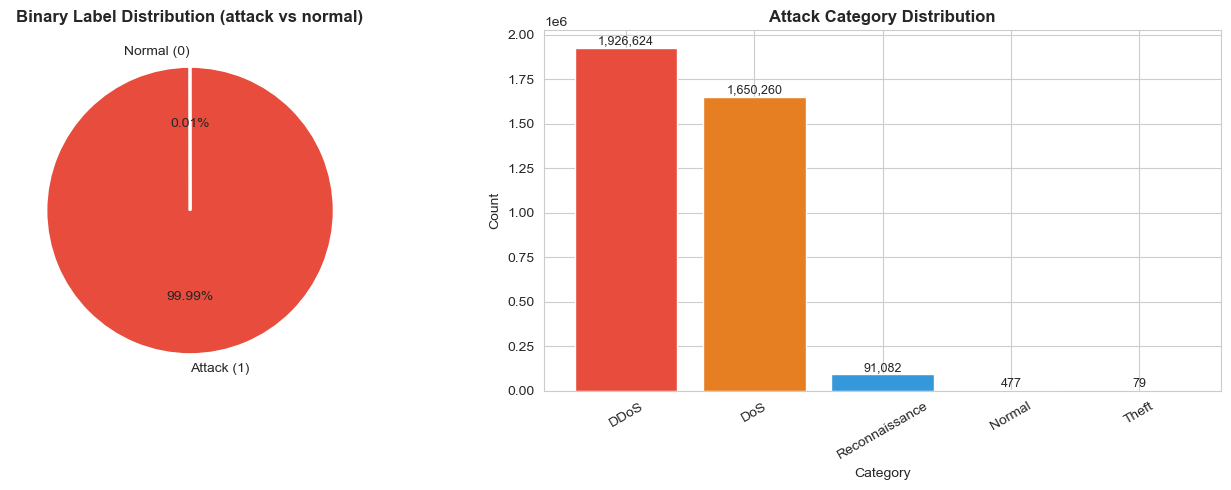


=== CLASS COUNTS ===
category
DDoS              1926624
DoS               1650260
Reconnaissance      91082
Normal                477
Theft                  79

Imbalance ratio: 7689.8:1


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary: attack vs normal
binary_counts = df['attack'].value_counts().sort_index()
labels_bin = ['Normal (0)', 'Attack (1)']
axes[0].pie(
    binary_counts.values,
    labels=labels_bin,
    autopct='%1.2f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Binary Label Distribution (attack vs normal)', fontsize=12, fontweight='bold')

# Multi-class: category
cat_counts = df['category'].value_counts()
colors_cat = ['#e74c3c', '#e67e22', '#3498db', '#9b59b6', '#1abc9c', '#2ecc71']
bars = axes[1].bar(cat_counts.index, cat_counts.values, color=colors_cat[:len(cat_counts)])
axes[1].set_title('Attack Category Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, cat_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== CLASS COUNTS ===')
print(cat_counts.to_string())
print(f'\nImbalance ratio: {binary_counts.max()/binary_counts.min():.1f}:1')

## 5. Feature Correlation with Attack Label

=== FEATURE CORRELATION WITH ATTACK LABEL ===
srate                0.093502
N_IN_Conn_P_DstIP    0.052785
N_IN_Conn_P_SrcIP    0.029041
seq                  0.016925
max                  0.015207
mean                 0.013011
stddev               0.012029
min                  0.005409
state_number         0.002560
drate                0.002002


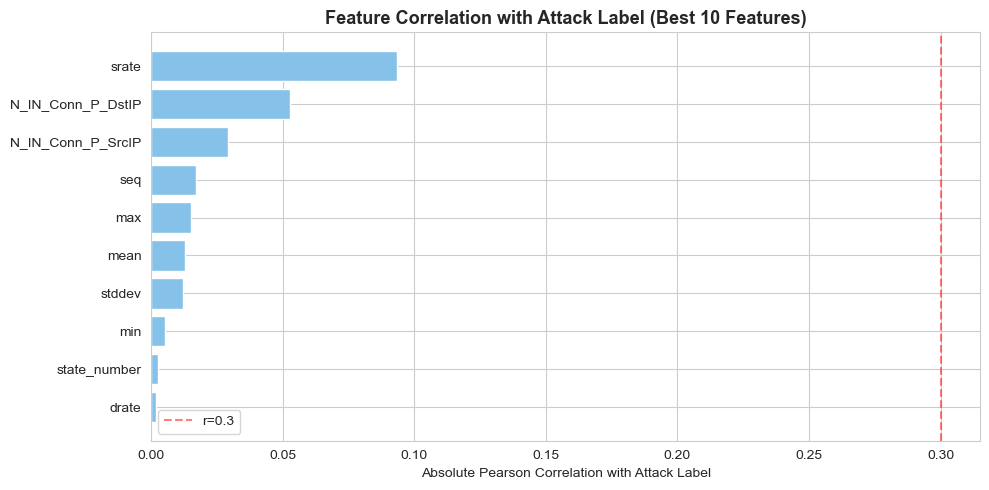

In [8]:
numeric_df = df[FEATURE_COLS + ['attack']]
corr_with_label = numeric_df.corr()['attack'].drop('attack').abs().sort_values(ascending=False)

print('=== FEATURE CORRELATION WITH ATTACK LABEL ===')
print(corr_with_label.to_string())

plt.figure(figsize=(10, 5))
colors = ['#1A5276' if v > 0.3 else '#2980B9' if v > 0.1 else '#85C1E9'
          for v in corr_with_label.values]
plt.barh(corr_with_label.index[::-1], corr_with_label.values[::-1], color=colors[::-1])
plt.xlabel('Absolute Pearson Correlation with Attack Label')
plt.title('Feature Correlation with Attack Label (Best 10 Features)', fontsize=13, fontweight='bold')
plt.axvline(x=0.3, color='red', linestyle='--', alpha=0.5, label='r=0.3')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/eda_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlation Heatmap

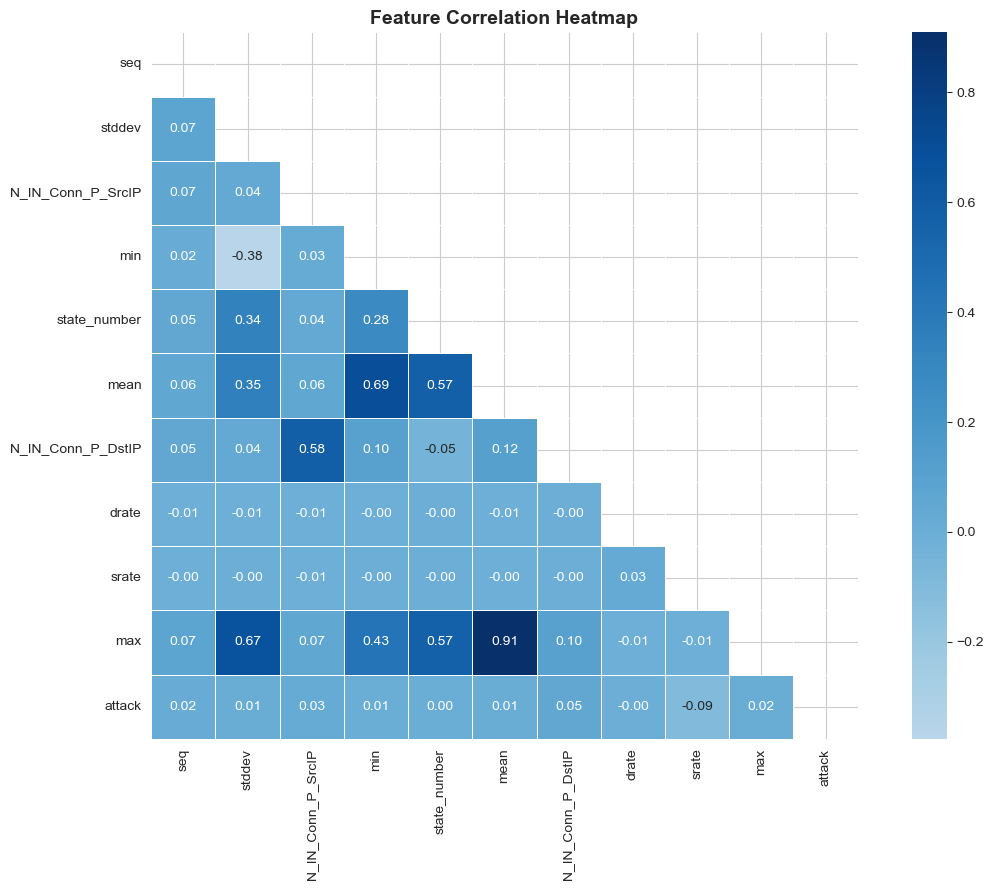

In [9]:
corr_matrix = numeric_df.corr()
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='Blues', center=0, square=True,
    linewidths=0.5, annot_kws={'size': 10}
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Per-Feature Distribution by Attack Category

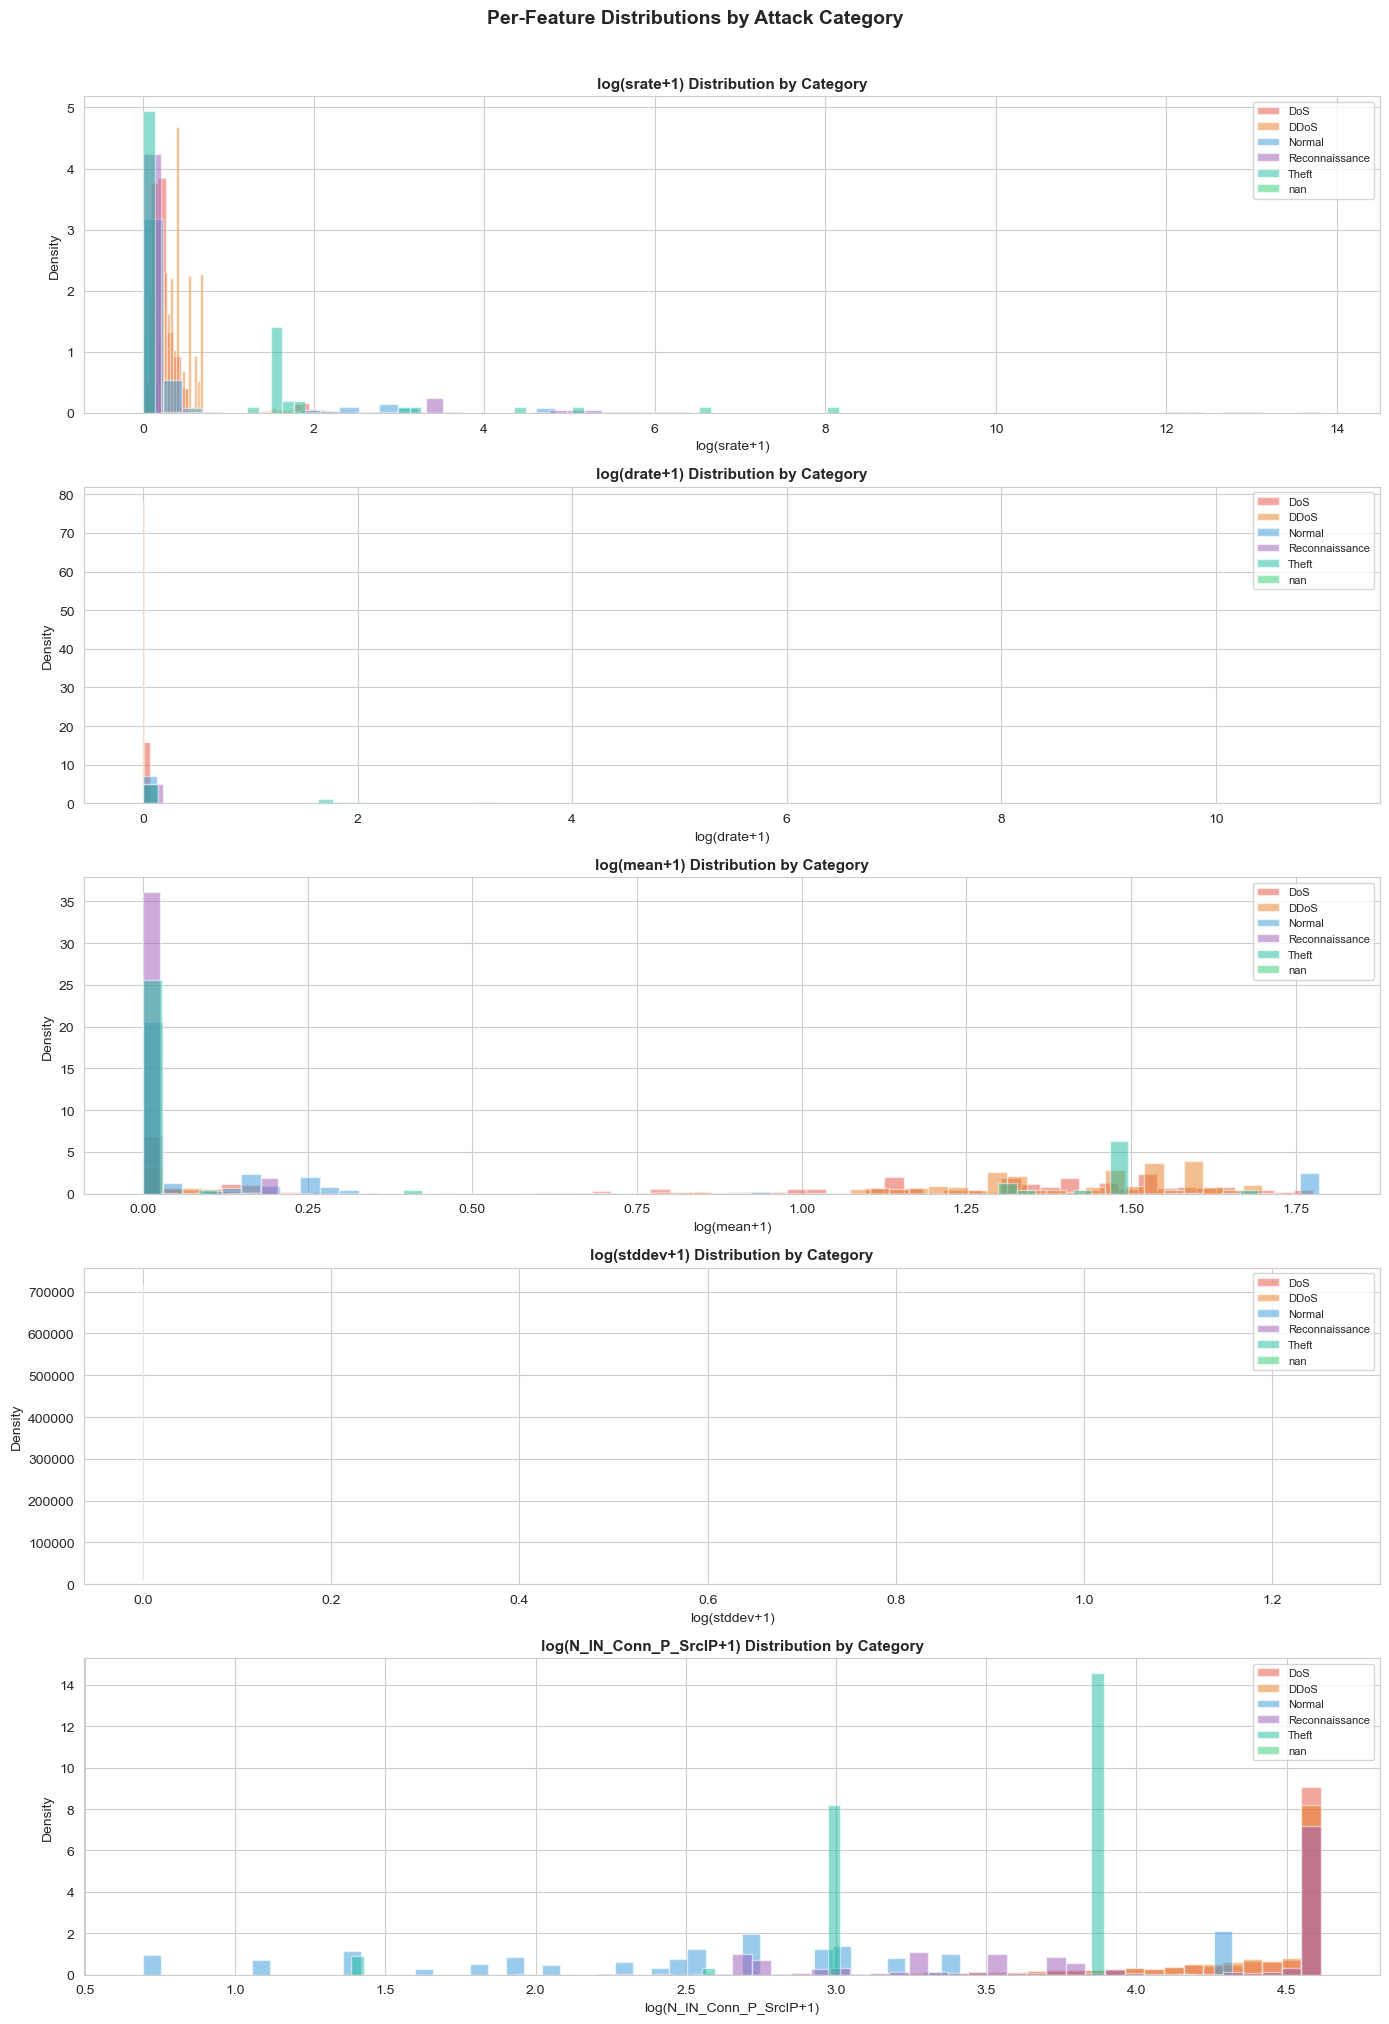

In [10]:
key_features = ['srate', 'drate', 'mean', 'stddev', 'N_IN_Conn_P_SrcIP']
categories = df['category'].unique()
colors_map = ['#e74c3c','#e67e22','#3498db','#9b59b6','#1abc9c','#2ecc71']

fig, axes = plt.subplots(len(key_features), 1, figsize=(14, 4 * len(key_features)))

for i, feat in enumerate(key_features):
    for j, cat in enumerate(categories):
        subset = df[df['category'] == cat][feat].dropna()
        subset_log = np.log1p(subset.clip(lower=0))
        axes[i].hist(subset_log, bins=60, alpha=0.5,
                     label=cat, density=True,
                     color=colors_map[j % len(colors_map)])
    axes[i].set_title(f'log({feat}+1) Distribution by Category', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(f'log({feat}+1)')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Per-Feature Distributions by Attack Category', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/eda_per_attack_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. EDA Summary

In [11]:
print('=' * 55)
print('EDA SUMMARY')
print('=' * 55)
print(f'Total records:        {len(df):,}')
print(f'Feature columns:      {len(FEATURE_COLS)}')
print(f'Attack categories:    {df["category"].nunique()}')
print(f'Null values:          {df.isnull().sum().sum()}')
print(f'Duplicate rows:       {df.duplicated().sum():,}')
print(f'Imbalance ratio:      {binary_counts.max()/binary_counts.min():.1f}:1')
print()
print('Feature correlations with attack label:')
for feat, corr in corr_with_label.items():
    print(f'  {feat:<25} r = {corr:.4f}')
print()
print('Next -> 02_Preprocessing.ipynb')

EDA SUMMARY
Total records:        7,337,044
Feature columns:      10
Attack categories:    5
Null values:          73370440
Duplicate rows:       0
Imbalance ratio:      7689.8:1

Feature correlations with attack label:
  srate                     r = 0.0935
  N_IN_Conn_P_DstIP         r = 0.0528
  N_IN_Conn_P_SrcIP         r = 0.0290
  seq                       r = 0.0169
  max                       r = 0.0152
  mean                      r = 0.0130
  stddev                    r = 0.0120
  min                       r = 0.0054
  state_number              r = 0.0026
  drate                     r = 0.0020

Next -> 02_Preprocessing.ipynb
